In [1]:
import sys
sys.path.append(r'E:\Zixin\Optimisation\spopt\spopt\locate')
from frlm import FRLM
import networkx as nx
import numpy as np
import numpy as np
import pandas as pd
import networkx as nx
import pulp
import matplotlib.pyplot as plt

#### create network 

In [2]:
G = nx.grid_2d_graph(5, 5)
mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, mapping)
for u, v in G.edges():
    G[u][v]['length'] = np.random.uniform(60000, 120000)  # Random distances 10-50 km
pos = {}
for i, (x, y) in enumerate([(i//5, i%5) for i in range(25)]):
    pos[i] = (x*100, y*100)  
nx.set_node_attributes(G, pos, 'pos')

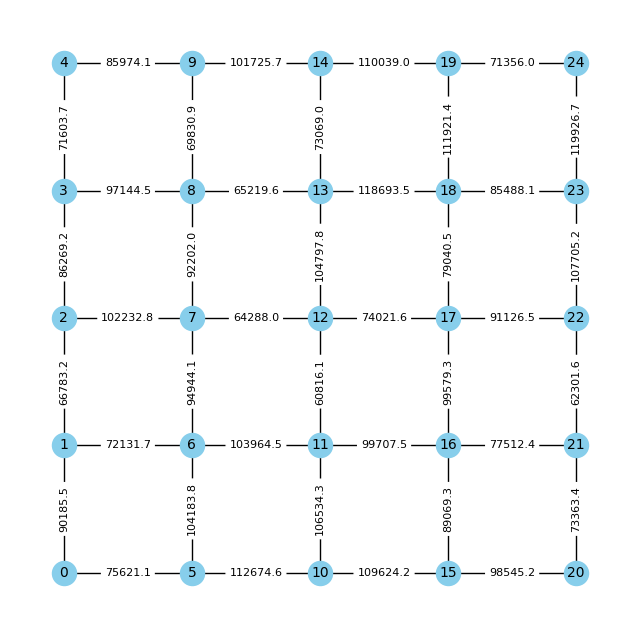

In [3]:
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G, pos)
edge_labels = {(u, v): f"{d['length']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
nx.draw_networkx_labels(G, pos, font_size=10)
plt.axis('off')
plt.show()

#### create sample flows

In [4]:
np.random.seed(42) 
    
flows_data = []
    

od_pairs = [ (0, 24, 150),   
        (4, 20, 120),   
        (12, 12, 0),    
        (2, 22, 80),   
        (1, 23, 90),   
        (5, 19, 60),    
        (10, 14, 70),  
        (3, 21, 45),    
        (7, 17, 35),   
        (6, 18, 25),   
        (8, 16, 40),   
        (9, 15, 55),    
        (11, 13, 30),  
        (0, 12, 95),   
        (12, 24, 110)]

for origin, dest, volume in od_pairs:
    if origin != dest and volume > 0: 
        flows_data.append({
            'origin': origin,
            'destination': dest, 
                'volume': volume
        })
    
flows_df = pd.DataFrame(flows_data)


In [5]:
print(flows_df)

    origin  destination  volume
0        0           24     150
1        4           20     120
2        2           22      80
3        1           23      90
4        5           19      60
5       10           14      70
6        3           21      45
7        7           17      35
8        6           18      25
9        8           16      40
10       9           15      55
11      11           13      30
12       0           12      95
13      12           24     110


#### FRLM

##### solve with greedy - basic

In [47]:
network = G
flows_df = flows_df

In [48]:
frlm = FRLM( 
        p=5,                   # Locate 5 facilities
        capacitated=False      # Basic model
        # default vehicle range is 200000 meter, optionally, n % of longest path if specified 
    )


Initialised FRLM with vehicle_range=200000.0, p=5, capacitated=False (unlimited capacity)


In [49]:
frlm.load_network(network)
frlm.load_flows_from_dataframe(flows_df)

Loaded network with 25 nodes and 40 edges


In [50]:
# greedy solver 
result = frlm.solve(solver="greedy")
frlm.print_solution_summary()

Generated K set with 68 entries and A set with 14 paths

Greedy Basic FRLM Solution:
Selected 5 facilities
Covered 13 flows (88.06% of total flow)
Total flow covered: 885.00
Solution time: 0.00 seconds

FLOW REFUELING LOCATION MODEL - SOLUTION SUMMARY
Model Type: Basic
Solver Type: greedy
Vehicle Range: 200000.0
Facilities to Locate: 5

Solution Status: Heuristic
Solution Time: 0.00 seconds
Objective Value: 885.0000

Facility Locations (5 modules at 5 sites):
  - Site 1
  - Site 8
  - Site 12
  - Site 17
  - Site 19

Flow Coverage:
  - Total Flow: 1005.00
  - Covered Flow: 885.00
  - Coverage Percentage: 88.06%
  - Fully Covered Flows: 13 / 14
  - Partially Covered Flows: 0 / 14
  - Uncovered Flows: 1 / 14

Solver Information:
  - Greedy Iterations: 5
  - Total Candidates Evaluated: 110
  - Avg Candidates per Iteration: 22.0
  - Marginal Benefits Available: 24 facilities


In [51]:
result = frlm.solve(solver="greedy")

print(f"\nLagrange Multipliers (Shadow Prices):")
shadow_prices = frlm.get_shadow_prices()
for constraint, price in shadow_prices.items():
    if abs(price) > 1e-6:
        print(f"  {constraint}: π = {price:.4f}")

print(f"\nDecision Variables:")
variables = frlm.get_variable_values()
for var_name, value in variables.items():
    if abs(value) > 1e-6:
        print(f"  {var_name}: {value}")

model = frlm.problem  
print(f"  Model type: {type(model)}")



Greedy Basic FRLM Solution:
Selected 5 facilities
Covered 13 flows (88.06% of total flow)
Total flow covered: 885.00
Solution time: 0.00 seconds

Lagrange Multipliers (Shadow Prices):
  facility_count: π = 120.0000
  coverage_0_24: π = 150.0000
  coverage_2_22: π = 80.0000
  coverage_1_23: π = 90.0000
  coverage_5_19: π = 60.0000
  coverage_10_14: π = 70.0000
  coverage_3_21: π = 45.0000
  coverage_7_17: π = 35.0000
  coverage_6_18: π = 25.0000
  coverage_8_16: π = 40.0000
  coverage_9_15: π = 55.0000
  coverage_11_13: π = 30.0000
  coverage_0_12: π = 95.0000
  coverage_12_24: π = 110.0000

Decision Variables:
  x_1: 1.0
  x_8: 1.0
  x_12: 1.0
  x_17: 1.0
  x_19: 1.0
  y_0_24: 1.0
  y_2_22: 1.0
  y_1_23: 1.0
  y_5_19: 1.0
  y_10_14: 1.0
  y_3_21: 1.0
  y_7_17: 1.0
  y_6_18: 1.0
  y_8_16: 1.0
  y_9_15: 1.0
  y_11_13: 1.0
  y_0_12: 1.0
  y_12_24: 1.0
  Model type: <class 'frlm.FRLM._create_greedy_problem_view.<locals>.GreedyProblemView'>


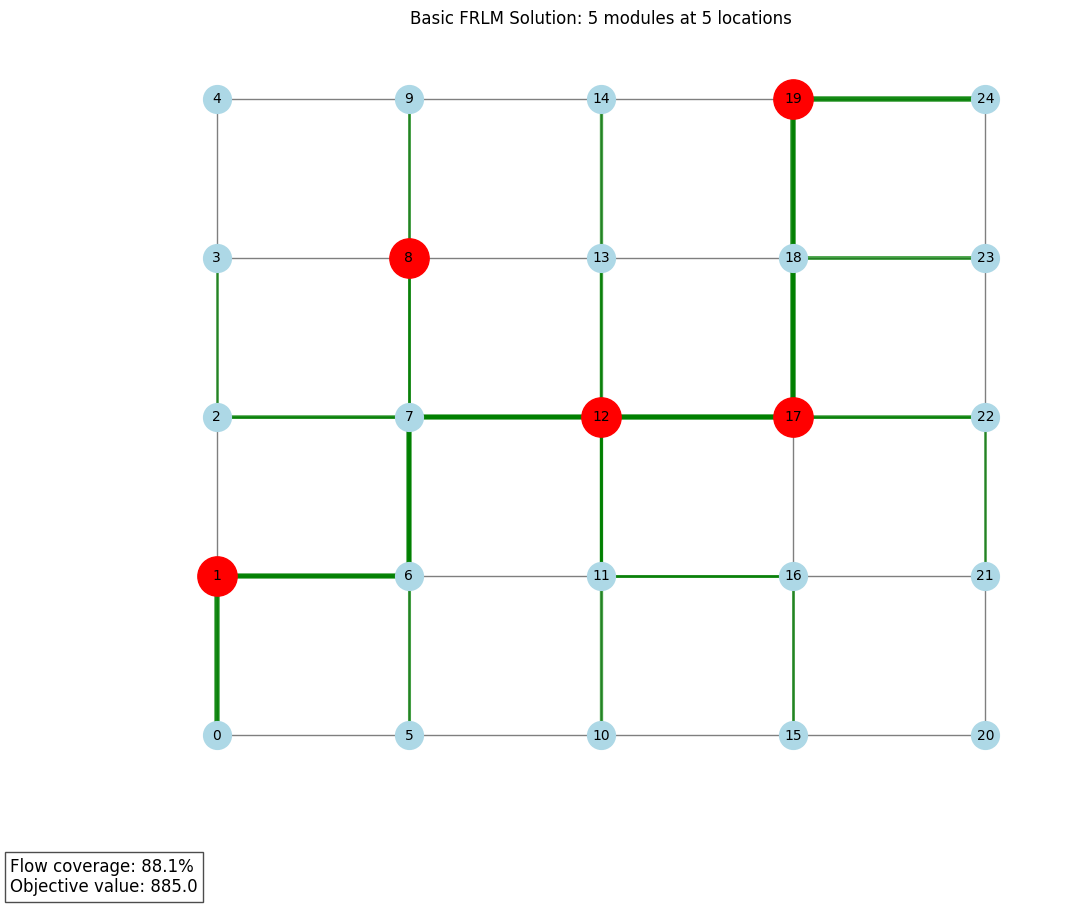

In [52]:
frlm.visualize_solution( 
    show_flows=True,                 
    node_size=400,                    
    facility_size=800,               
    node_color='lightblue',         
    facility_color='red'             
)

##### solve pulp -capacited

In [38]:
network = G
flows_df = flows_df


In [39]:
frlm = FRLM( 
        vehicle_range = '20%',
        p=5,    
        capacity = 150,            
        capacitated=True      
    )

Initialised FRLM with vehicle_range=20%, p=5, capacity=150, capacitated=True
Vehicle range set to 20% of longest path after loading flows


In [40]:
frlm.load_network(network)
frlm.load_flows_from_dataframe(flows_df)

Loaded network with 25 nodes and 40 edges


In [42]:
# exact solver 
solver = pulp.PULP_CBC_CMD(msg=True, timeLimit=60) 
result = frlm.solve(solver=solver)
frlm.print_solution_summary()



PuLP Capacitated FRLM Solution:
Status: Optimal
Objective value (flow): 92.50
Total flow covered: 92.50 / 1005.00 (9.20%)
Modules located at 5 locations:
  - Location 12: 1 module(s)
  - Location 17: 1 module(s)
  - Location 18: 1 module(s)
  - Location 19: 1 module(s)
  - Location 24: 1 module(s)
Solution time: 1.49 seconds

FLOW REFUELING LOCATION MODEL - SOLUTION SUMMARY
Model Type: Capacitated
Solver Type: pulp
Vehicle Range: 131577.7593251886
Facilities to Locate: 5
Facility Capacity: 150

Solution Status: Optimal
Solution Time: 1.49 seconds
Objective Value: 92.5000

Facility Locations (5 modules at 5 sites):
  - Site 12: 1 module(s)
  - Site 17: 1 module(s)
  - Site 18: 1 module(s)
  - Site 19: 1 module(s)
  - Site 24: 1 module(s)

Flow Coverage:
  - Total Flow: 1005.00
  - Covered Flow: 92.50
  - Coverage Percentage: 9.20%
  - Fully Covered Flows: 1 / 14
  - Partially Covered Flows: 1 / 14
  - Uncovered Flows: 12 / 14

Solver Information:
  - Number of Variables: 4169
  - Numbe

In [45]:
result = frlm.solve(pulp.PULP_CBC_CMD(msg=True, timeLimit=60))

print(f"\nLagrange Multipliers:")
shadow_prices = frlm.get_shadow_prices()
for constraint, price in shadow_prices.items():
    if abs(price) > 1e-6:
        print(f"  {constraint}: π = {price:.4f}")

print(f"\nDecision Variables:")
variables = frlm.get_variable_values()
for var_name, value in variables.items():
    if abs(value) > 1e-6:
        print(f"  {var_name}: {value}")

model = frlm.problem
print(f" Model type: {type(model)}")



PuLP Capacitated FRLM Solution:
Status: Optimal
Objective value (flow): 92.50
Total flow covered: 92.50 / 1005.00 (9.20%)
Modules located at 5 locations:
  - Location 12: 1 module(s)
  - Location 17: 1 module(s)
  - Location 18: 1 module(s)
  - Location 19: 1 module(s)
  - Location 24: 1 module(s)
Solution time: 1.49 seconds

Lagrange Multipliers:
  capacity_7: π = 0.5000
  capacity_13: π = 1.0000
  capacity_17: π = 0.5000
  flow_coverage_7: π = 17.5000

Decision Variables:
  x_12: 1.0
  x_17: 1.0
  x_18: 1.0
  x_19: 1.0
  x_24: 1.0
  y_13_0: 0.52272727
  y_7_0: 1.0
 Model type: <class 'pulp.pulp.LpProblem'>


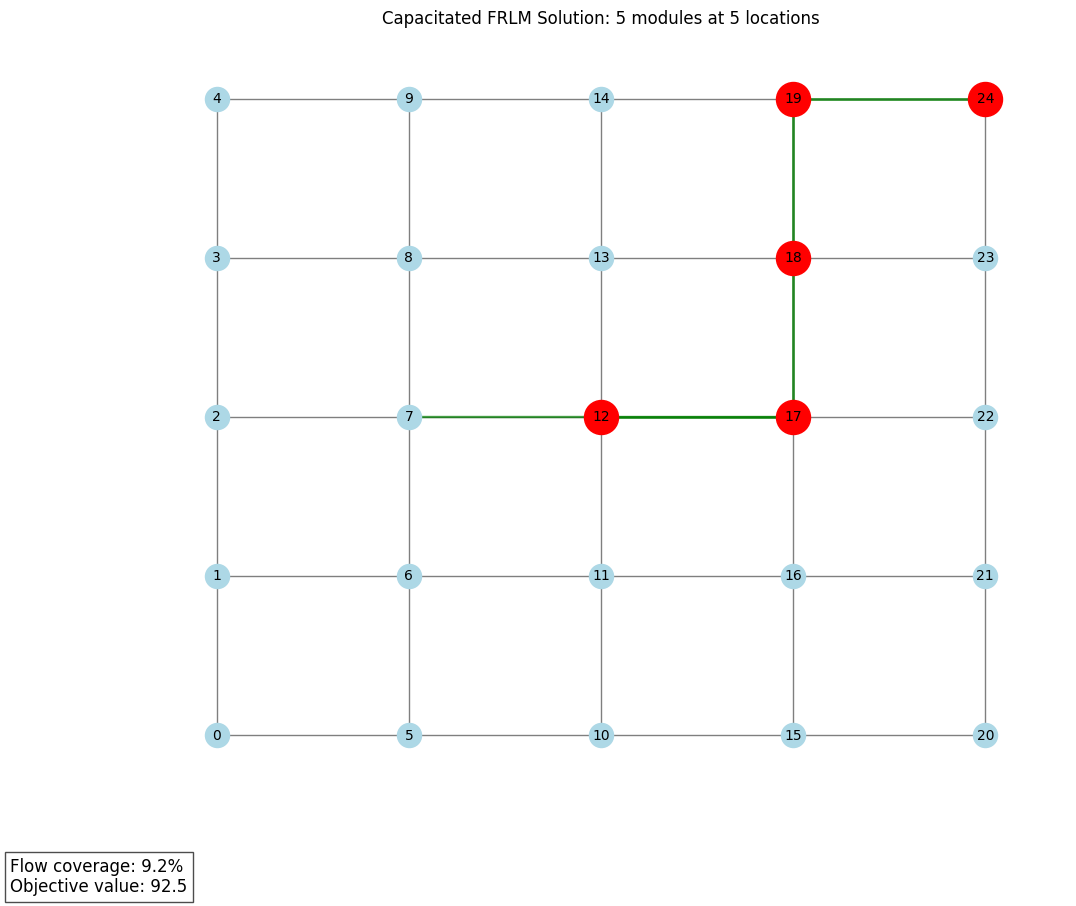

In [46]:
frlm.visualize_solution(show_flows=True)